# 004_strategy

**Author:** Wayne Kirk Schmidt  
**Email:** wayne.kirk.schmidt@gmail.com

## Purpose

This stage converts structured event-response data into **evaluated trading candidates**.

Rather than defining a deployable trading system, this stage focuses on:
- measuring directional consistency of cross-asset reactions
- identifying repeatable lead–lag behavior
- constructing candidate signals for evaluation

The goal is to determine whether observed relationships represent:
- noise
- weak statistical signal
- or viable strategy candidates

## Inputs

This notebook consumes artifacts from:

* output/002_enrich/
* output/003_analysis/

Specifically:

- `reaction_panel.pkl` — event-level return responses across assets
- `shock_events.pkl` — identified shock events from analysis stage
- `sigma_event_matrix.pkl` — event structure and alignment signals
- `event_bitmap.pkl` *(diagnostic)* — cross-asset activation structure

## Analysis Goals

This stage performs four key tasks:

* 1. Construct Event Response Dataset
Build a unified dataset describing how assets respond following a reference asset shock.

* 2. Measure Directional Consistency
Evaluate whether follower assets move in the expected direction relative to the initiating event.

* 3. Identify Aligned Events
Filter events where direction and magnitude meet consistency criteria.

* 4. Aggregate Pair-Level Statistics
Compute hit rates and frequencies for asset pairs to assess signal strength.

## Outputs

Artifacts generated by this stage:

- `event_response_df.pkl` — base event response dataset  
- `event_response_expanded.pkl` — enriched dataset with derived features  
- `trade_df.pkl` — mapped trade representation of signals  
- `daily_returns.pkl` — aggregated return series  
- `reduced_df.pkl` — filtered dataset of aligned events  
- `pair_hit.pkl` — pair-level hit rate statistics  

These artifacts are written to:

* output/004_strategy/

and registered in the pipeline `manifest.pkl`.

## Pipeline Position

The pipeline follows the following steps:

- 001_download --> data acquisition
- 002_enrich --> transformation and enrichment
- 003_analysis --> statistical structure  
- **004_strategy --> exploration and hypothesis evaluation**
- 005_backtest --> execution mapping and performance evaluation  

## Design Principle

This stage follows these principles:

- **Deterministic pipeline** — no recomputation of prior stages
- **No forward assumptions** — all results derived from observed data
- **Separation from backtesting** — evaluation only, not deployment
- **Full artifact persistence** — every transformation is saved

This stage intentionally stops short of claiming a tradable strategy,
and instead produces **evidence for or against a statistical edge**.

### 1. Imports and Environment Setup
### Provide the necessary imports required for to to proceed.   

In [16]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Prepare the environment for the notebook

In [17]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "004_strategy"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 3. Loading the manifest pickle file

In [18]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{}

### 4. Load the pickle files from the previous stage
We use these file contents for our analysis.

In [19]:

# 001_download artifacts
prices = pd.read_pickle(DOWNLOAD_DIR / "PRICES.pkl")
event_panels = {}
for coin in universe:
    panel_file = DOWNLOAD_DIR / f"{coin}.event_panel.pkl"
    event_panels[coin] = pd.read_pickle(panel_file)

# 002_enrich artifacts
returns_full = pd.read_pickle(ENRICH_DIR / "returns_full.pkl")
z_scores = pd.read_pickle(ENRICH_DIR / "z_scores.pkl")
rolling_sigma = pd.read_pickle(ENRICH_DIR / "rolling_sigma.pkl")
price_wide = pd.read_pickle(ENRICH_DIR / "price_wide.pkl")

# 003_analysis artifacts
event_bitmap = pd.read_pickle(ANALYSIS_DIR / "event_bitmap.pkl")
extreme_z_scores = pd.read_pickle(ANALYSIS_DIR / "extreme_z_scores.pkl")
sigma_event_matrix = pd.read_pickle(ANALYSIS_DIR / "sigma_event_matrix.pkl")

print("prices:", prices.shape)
print("returns_full:", returns_full.shape)
print("z_scores:", z_scores.shape)
print("rolling_sigma:", rolling_sigma.shape)
print("price_wide:", price_wide.shape)
print("event_bitmap:", event_bitmap.shape)
print("extreme_z_scores:", extreme_z_scores.shape)
print("sigma_event_matrix:", sigma_event_matrix.shape)
print("event panels loaded:", list(event_panels.keys()))

prices: (10417, 5)
returns_full: (984, 9)
z_scores: (965, 9)
rolling_sigma: (965, 9)
price_wide: (1179, 9)
event_bitmap: (19, 11)
extreme_z_scores: (9, 5)
sigma_event_matrix: (9, 5)
event panels loaded: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LTCUSDT']


### 5. Reconstruct sigma_class from sigma_event_matrix

In [20]:
assert "sigma_event_matrix" in locals(), "sigma_event_matrix not loaded"

sigma_class = (z_scores > sigma_threshold).astype(int) - (z_scores < -sigma_threshold).astype(int)

print("max:", z_scores.max().max())
print("min:", z_scores.min().min())
print("event_count:", ((z_scores >= 3) | (z_scores <= -3)).sum().sum())

sigma_class = (z_scores >= sigma_threshold).astype(int) - (z_scores <= -sigma_threshold).astype(int)

assert sigma_class.shape == z_scores.shape
assert int((sigma_class != 0).sum().sum()) == 104

print("OK:", sigma_class.shape, "events:", int((sigma_class != 0).sum().sum()))

max: 4.281477768984525
min: -4.155916934268655
event_count: 104
OK: (965, 9) events: 104


### 6. Review Shock Events

In [21]:
sigma_class = np.floor(z_scores).astype(int)

# count signed sigma values
sigma_counts = sigma_class.stack().value_counts().sort_index()

print(sigma_counts)

-5       4
-4      40
-3     184
-2     892
-1    3224
 0    3059
 1     954
 2     268
 3      58
 4       2
Name: count, dtype: int64


### 7. Explore breakdown of events

In [22]:
# count by signed sigma and coin
pd.set_option("display.width", 2000)
pd.set_option("display.max_columns", None)
stacked = sigma_class.stack()

sigma_coin_counts = (
    stacked
    .groupby([stacked, stacked.index.get_level_values(1)])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

extreme_mask = (sigma_coin_counts.index <= -3) | (sigma_coin_counts.index >= 3)

print(sigma_coin_counts)

coin  ADAUSDT  AVAXUSDT  BNBUSDT  BTCUSDT  DOGEUSDT  ETHUSDT  LTCUSDT  SOLUSDT  XRPUSDT
-5          0         0        0        1         0        1        0        0        2
-4          6         3        5        3         3        5        7        3        5
-3         16        19       27       24        21       22       19       18       18
-2        111       109       89       91        91      102       96      108       95
-1        367       356      333      356       383      340      357      354      378
 0        325       335      367      340       329      355      356      314      338
 1        104       107      102      112       102      107      100      130       90
 2         33        31       35       31        28       26       22       33       29
 3          2         5        7        7         8        6        8        5       10
 4          1         0        0        0         0        1        0        0        0


### 8. apply the mask to get number of extreme events per coin

In [23]:
extreme_sigma_coin_counts = sigma_coin_counts.loc[extreme_mask]

print(extreme_sigma_coin_counts)

coin  ADAUSDT  AVAXUSDT  BNBUSDT  BTCUSDT  DOGEUSDT  ETHUSDT  LTCUSDT  SOLUSDT  XRPUSDT
-5          0         0        0        1         0        1        0        0        2
-4          6         3        5        3         3        5        7        3        5
-3         16        19       27       24        21       22       19       18       18
 3          2         5        7        7         8        6        8        5       10
 4          1         0        0        0         0        1        0        0        0


### 9. reorganize sigma, coin, and date

In [24]:
leader_mask = (sigma_class >= 3) | (sigma_class <= -3)
leader_events = sigma_class.where(leader_mask)

# convert to long format
event_df = (
    leader_events
    .stack()
    .reset_index()
)

# standardize column names
event_df.columns = ["event_date", "reference_coin", "sigma"]

event_df["sigma"] = event_df["sigma"].astype(int)

# sort for sanity
event_df = event_df.sort_values(["event_date", "reference_coin"]).reset_index(drop=True)

# quick checks
print("event_df shape:", event_df.shape)
print(event_df.head())

event_df shape: (288, 3)
                 event_date reference_coin  sigma
0 2023-08-03 00:00:00+00:00        LTCUSDT     -3
1 2023-08-15 00:00:00+00:00       AVAXUSDT     -3
2 2023-08-15 00:00:00+00:00       DOGEUSDT     -3
3 2023-08-15 00:00:00+00:00        SOLUSDT     -3
4 2023-08-15 00:00:00+00:00        XRPUSDT     -3


### 10. Attach forward return vectors

In [25]:
all_coins = price_wide.columns.tolist()

records = []

for _, row in event_df.iterrows():
    event_date = row["event_date"]
    ref_coin = row["reference_coin"]
    sigma = row["sigma"]

    # locate event index
    if event_date not in price_wide.index:
        continue

    idx = price_wide.index.get_loc(event_date)

    for target_coin in all_coins:
        if target_coin == ref_coin:
            continue

        # ensure full forward window exists
        if idx + observation_window_length >= len(price_wide):
            continue

        # extract forward prices
        price_series = price_wide[target_coin].iloc[idx : idx + observation_window_length + 1]

        # convert to returns
        returns = price_series.pct_change().iloc[1:].values

        if len(returns) != observation_window_length:
            continue

        records.append({
            "event_date": event_date,
            "reference_coin": ref_coin,
            "target_coin": target_coin,
            "sigma": sigma,
            "returns_vector": returns
        })

event_response_df = pd.DataFrame(records)

print("event_response_df shape:", event_response_df.shape)
print(event_response_df.head())

EVENT_RESPONSE_RAW_FILE = STRATEGY_DIR / "event_response_df.pkl"
event_response_df.to_pickle(EVENT_RESPONSE_RAW_FILE)
manifest[stage_label]["event_response_df"] = str(EVENT_RESPONSE_RAW_FILE)
print("saved:", EVENT_RESPONSE_RAW_FILE)
print("shape:", event_response_df.shape)

event_response_df shape: (2304, 5)
                 event_date reference_coin target_coin  sigma                                     returns_vector
0 2023-08-03 00:00:00+00:00        LTCUSDT     ADAUSDT     -3  [0.004098360655737654, -0.0010204081632652073,...
1 2023-08-03 00:00:00+00:00        LTCUSDT    AVAXUSDT     -3  [-0.003212851405622441, 0.00241740531829171, 0...
2 2023-08-03 00:00:00+00:00        LTCUSDT     BNBUSDT     -3  [0.0016625103906899863, 0.007883817427385864, ...
3 2023-08-03 00:00:00+00:00        LTCUSDT     BTCUSDT     -3  [-0.00256893391640145, -0.0018550830546302244,...
4 2023-08-03 00:00:00+00:00        LTCUSDT    DOGEUSDT     -3  [-0.0017643865363733413, 0.028687967369136702,...
saved: ../output/004_strategy/event_response_df.pkl
shape: (2304, 5)


### 11. attach the values for returns into a vector we can use

In [26]:
lags = 10

# expand returns_vector into columns
returns_expanded = pd.DataFrame(
    event_response_df["returns_vector"].tolist(),
    columns=[f"lag_{i+1}" for i in range(lags)]
)

# combine back
event_response_expanded = pd.concat(
    [event_response_df.drop(columns=["returns_vector"]), returns_expanded],
    axis=1
)

print(event_response_expanded.shape)
print(event_response_expanded.head())

EVENT_RESPONSE_EXPANDED_FILE = STRATEGY_DIR / "event_response_expanded.pkl"
event_response_expanded.to_pickle(EVENT_RESPONSE_EXPANDED_FILE)
manifest[stage_label]["event_response_expanded"] = str(EVENT_RESPONSE_EXPANDED_FILE)
print("saved:", EVENT_RESPONSE_EXPANDED_FILE)
print("shape:", event_response_expanded.shape)


(2304, 14)
                 event_date reference_coin target_coin  sigma     lag_1     lag_2     lag_3     lag_4     lag_5     lag_6     lag_7     lag_8     lag_9    lag_10
0 2023-08-03 00:00:00+00:00        LTCUSDT     ADAUSDT     -3  0.004098 -0.001020 -0.006129 -0.003768  0.023384  0.011089 -0.014955 -0.009447 -0.006131 -0.006511
1 2023-08-03 00:00:00+00:00        LTCUSDT    AVAXUSDT     -3 -0.003213  0.002417  0.011254 -0.011924  0.021722 -0.004724 -0.011867 -0.004804 -0.004023 -0.008078
2 2023-08-03 00:00:00+00:00        LTCUSDT     BNBUSDT     -3  0.001663  0.007884  0.000412 -0.004938  0.014475 -0.006115 -0.010254 -0.005387  0.000417  0.000416
3 2023-08-03 00:00:00+00:00        LTCUSDT     BTCUSDT     -3 -0.002569 -0.001855  0.000888  0.003721  0.019690 -0.006716 -0.004086 -0.000918 -0.000073 -0.003871
4 2023-08-03 00:00:00+00:00        LTCUSDT    DOGEUSDT     -3 -0.001764  0.028688 -0.017182 -0.011565  0.020952  0.004797  0.005570 -0.001846  0.013742 -0.024374
saved: ../output/

### 12. Mean response by sigma and lag

In [27]:
lag_cols = [f"lag_{i+1}" for i in range(10)]

sigma_response = (
    event_response_expanded
    .groupby("sigma")[lag_cols]
    .mean()
    .sort_index()
)

print(sigma_response)

          lag_1     lag_2     lag_3     lag_4     lag_5     lag_6     lag_7     lag_8     lag_9    lag_10
sigma                                                                                                    
-5     0.031235  0.005290  0.004586 -0.014319 -0.018990  0.012551 -0.006291  0.006079  0.009411 -0.002635
-4     0.023121  0.015307  0.008495 -0.006337 -0.010505  0.022606 -0.015286  0.013943  0.011418 -0.008052
-3     0.000979  0.004238 -0.000655  0.002586 -0.004354  0.013425 -0.007493  0.007244 -0.002948  0.000122
 3     0.001176  0.015192 -0.001047  0.001384  0.005148 -0.004364 -0.004639 -0.003317  0.009706  0.005610
 4    -0.043455  0.012152  0.020587 -0.029966 -0.013297  0.039237 -0.058328 -0.025557  0.024736  0.023787


### 13. Exploratory: Focus on sigma = -3 only

In [28]:
sigma3 = event_response_expanded[
    event_response_expanded["sigma"] == -3
]

sigma3_mean = sigma3[lag_cols].mean()

print(sigma3_mean)

lag_1     0.000979
lag_2     0.004238
lag_3    -0.000655
lag_4     0.002586
lag_5    -0.004354
lag_6     0.013425
lag_7    -0.007493
lag_8     0.007244
lag_9    -0.002948
lag_10    0.000122
dtype: float64


### 14. Plot the results for the lags to see if any patterns.

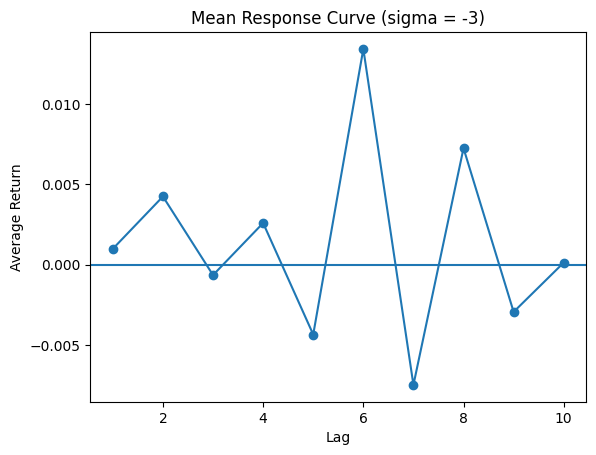

In [29]:
lags = list(range(1, 11))
values = sigma3_mean.values

plt.figure()
plt.plot(lags, values, marker='o')
plt.axhline(0)

plt.title("Mean Response Curve (sigma = -3)")
plt.xlabel("Lag")
plt.ylabel("Average Return")

plt.show()

### 15. Plot all events, to see the vectors

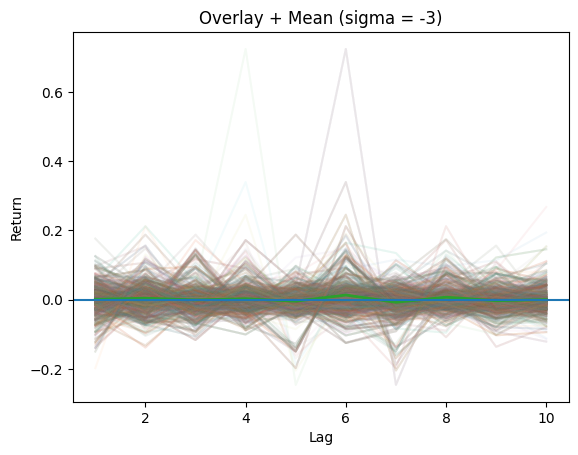

In [30]:
lags = list(range(1, 11))

# use RAW dataframe (has returns_vector)
sigma3_raw = event_response_df[
    event_response_df["sigma"] == -3
]

plt.figure()

# overlay all paths
for vec in sigma3_raw["returns_vector"]:
    plt.plot(lags, vec, alpha=0.05)

# mean line (from expanded dataframe)
plt.plot(lags, sigma3_mean.values, linewidth=2)

plt.axhline(0)

plt.title("Overlay + Mean (sigma = -3)")
plt.xlabel("Lag")
plt.ylabel("Return")

plt.show()

### 16. Dispersion analysis per lag (sigma = -3)

In [31]:
lag_cols = [f"lag_{i+1}" for i in range(10)]

dispersion_df = pd.DataFrame({
    "mean": sigma3[lag_cols].mean(),
    "std": sigma3[lag_cols].std(),
})

# signal-to-noise proxy
dispersion_df["abs_mean"] = dispersion_df["mean"].abs()
dispersion_df["snr"] = dispersion_df["abs_mean"] / dispersion_df["std"]

print(dispersion_df.sort_index())

            mean       std  abs_mean       snr
lag_1   0.000979  0.047237  0.000979  0.020729
lag_10  0.000122  0.036284  0.000122  0.003364
lag_2   0.004238  0.045786  0.004238  0.092555
lag_3  -0.000655  0.045908  0.000655  0.014267
lag_4   0.002586  0.046073  0.002586  0.056134
lag_5  -0.004354  0.041042  0.004354  0.106086
lag_6   0.013425  0.066320  0.013425  0.202434
lag_7  -0.007493  0.045628  0.007493  0.164225
lag_8   0.007244  0.038653  0.007244  0.187411
lag_9  -0.002948  0.036422  0.002948  0.080928


### 17. Lag_5 to Lag_6 transition test

In [32]:
subset = sigma3.copy()

# condition: lag_5 negative
subset = subset[subset["lag_5"] < 0]

print("count:", len(subset))

print("\nlag_6 stats (given lag_5 < 0):")
print("mean:", subset["lag_6"].mean())
print("median:", subset["lag_6"].median())
print("positive_ratio:", (subset["lag_6"] > 0).mean())

count: 817

lag_6 stats (given lag_5 < 0):
mean: 0.014590768089947309
median: 0.009396902310288002
positive_ratio: 0.598531211750306


### 18. Refined test: sigma = -3 + lag_5 filters

In [33]:
# base filter: sigma = -3 only
subset = event_response_expanded[
    event_response_expanded["sigma"] == -3
].copy()

print("base count (sigma = -3):", len(subset))

### condition 1: lag_5 < 0
subset_weak = subset[subset["lag_5"] < 0]

print("\n--- Condition: lag_5 < 0 ---")
print("count:", len(subset_weak))
print("mean:", subset_weak["lag_6"].mean())
print("median:", subset_weak["lag_6"].median())
print("positive_ratio:", (subset_weak["lag_6"] > 0).mean())

### condition 2: lag_5 < -1% (stronger signal)
subset_strong = subset[subset["lag_5"] < -0.01]

print("\n--- Condition: lag_5 < -1% ---")
print("count:", len(subset_strong))
print("mean:", subset_strong["lag_6"].mean())
print("median:", subset_strong["lag_6"].median())
print("positive_ratio:", (subset_strong["lag_6"] > 0).mean())

base count (sigma = -3): 1472

--- Condition: lag_5 < 0 ---
count: 817
mean: 0.014590768089947309
median: 0.009396902310288002
positive_ratio: 0.598531211750306

--- Condition: lag_5 < -1% ---
count: 547
mean: 0.017958162340694507
median: 0.011550678602368025
positive_ratio: 0.5923217550274223


### 19. Conditioned leader --> follower test

In [34]:
### build base dataset
base = event_response_expanded.copy()

print("total rows:", len(base))

### condition filter (leader condition)
conditioned = base[
    (base["sigma"] == -3) &
    (base["lag_5"] < -0.01)
].copy()

print("\nconditioned rows:", len(conditioned))

### baseline (for comparison)
baseline = base[
    base["sigma"] == -3
].copy()

print("baseline rows:", len(baseline))

### function to compute stats
def summarize(df, label):
    print(f"\n--- {label} ---")
    
    for lag in ["lag_1", "lag_2", "lag_3"]:
        mean = df[lag].mean()
        median = df[lag].median()
        pos = (df[lag] > 0).mean()
        
        print(f"{lag}:")
        print(f"  mean:   {mean:.5f}")
        print(f"  median: {median:.5f}")
        print(f"  pos%:   {pos:.3f}")

### run comparison
summarize(baseline, "BASELINE (sigma = -3)")
summarize(conditioned, "CONDITIONED (sigma=-3 & lag_5<-1%)")

total rows: 2304

conditioned rows: 547
baseline rows: 1472

--- BASELINE (sigma = -3) ---
lag_1:
  mean:   0.00098
  median: 0.00225
  pos%:   0.531
lag_2:
  mean:   0.00424
  median: 0.00498
  pos%:   0.537
lag_3:
  mean:   -0.00065
  median: -0.00344
  pos%:   0.461

--- CONDITIONED (sigma=-3 & lag_5<-1%) ---
lag_1:
  mean:   -0.00966
  median: -0.00790
  pos%:   0.426
lag_2:
  mean:   0.01309
  median: 0.01458
  pos%:   0.645
lag_3:
  mean:   -0.00188
  median: 0.00053
  pos%:   0.519


### 20. FINAL SIGNAL VALIDATION (lag_2)

In [35]:
subset = event_response_expanded[
    (event_response_expanded["sigma"] == -3) &
    (event_response_expanded["lag_5"] < -0.01)
].copy()

lag = subset["lag_2"]

print("===== SAMPLE =====")
print("count:", len(lag))

print("\n===== CORE STATS =====")
print("mean:", lag.mean())
print("median:", lag.median())
print("std:", lag.std())

print("\n===== WIN / LOSS =====")
win_rate = (lag > 0).mean()
avg_win = lag[lag > 0].mean()
avg_loss = lag[lag <= 0].mean()

print("win_rate:", win_rate)
print("avg_win:", avg_win)
print("avg_loss:", avg_loss)
print("win/loss ratio:", avg_win / abs(avg_loss) if avg_loss != 0 else None)

print("\n===== TAIL RISK =====")
q = lag.quantile([0.01, 0.05, 0.1, 0.9, 0.95, 0.99])
print(q)

print("\n===== EXPECTED VALUE CHECK =====")
expected_value = win_rate * avg_win + (1 - win_rate) * avg_loss
print("expected_value:", expected_value)

===== SAMPLE =====
count: 547

===== CORE STATS =====
mean: 0.013085454873295698
median: 0.014584154513204384
std: 0.04282153500298594

===== WIN / LOSS =====
win_rate: 0.6453382084095064
avg_win: 0.0366040122959591
avg_loss: -0.029708621261756794
win/loss ratio: 1.2321006745297394

===== TAIL RISK =====
0.01   -0.096806
0.05   -0.065324
0.10   -0.041753
0.90    0.064272
0.95    0.088804
0.99    0.118180
Name: lag_2, dtype: float64

===== EXPECTED VALUE CHECK =====
expected_value: 0.013085454873295696


### 21. Trade mapping (conditional timing rule)

In [36]:

df = event_response_expanded.copy()

### signal condition
df["use_lag2"] = (
    (df["sigma"] == -3) &
    (df["lag_5"] < -0.01)
)

### choose return based on rule
df["signal_return"] = 0.0

# conditioned → lag_2
df.loc[df["use_lag2"], "signal_return"] = df.loc[df["use_lag2"], "lag_2"]

# default → lag_1 (only for sigma = -3 events)
default_mask = (df["sigma"] == -3) & (~df["use_lag2"])
df.loc[default_mask, "signal_return"] = df.loc[default_mask, "lag_1"]

### keep only actual trades
trade_df = df[df["signal_return"] != 0].copy()

print("total trades:", len(trade_df))
print("lag2 trades:", trade_df["use_lag2"].sum())
print("lag1 trades:", (~trade_df["use_lag2"]).sum())

TRADE_FILE = STRATEGY_DIR / "trade_df.pkl"
trade_df.to_pickle(TRADE_FILE)
manifest[stage_label]["trade_df"] = str(TRADE_FILE)
print("saved:", TRADE_FILE)
print("shape:", trade_df.shape)

total trades: 1470
lag2 trades: 547
lag1 trades: 923
saved: ../output/004_strategy/trade_df.pkl
shape: (1470, 16)


### 22. Build PnL time series

In [37]:
### aggregate by date (equal weight)
daily_returns = (
    trade_df
    .groupby("event_date")["signal_return"]
    .mean()
    .sort_index()
)

print("days:", len(daily_returns))
print("mean daily return:", daily_returns.mean())
print("std daily return:", daily_returns.std())

### equity curve
equity_curve = (1 + daily_returns).cumprod()

### basic stats
total_return = equity_curve.iloc[-1] - 1
volatility = daily_returns.std() * np.sqrt(trading_days)

sharpe = (
    daily_returns.mean() /
    daily_returns.std()
) * np.sqrt(trading_days)

drawdown = equity_curve / equity_curve.cummax() - 1
max_drawdown = drawdown.min()

print("\n===== PERFORMANCE =====")
print("total_return:", total_return)
print("volatility:", volatility)
print("sharpe:", sharpe)
print("max_drawdown:", max_drawdown)

DAILY_RETURNS_FILE = STRATEGY_DIR / "daily_returns.pkl"
daily_returns.to_pickle(DAILY_RETURNS_FILE)
manifest[stage_label]["daily_returns"] = str(DAILY_RETURNS_FILE)
print("saved:", DAILY_RETURNS_FILE)
print("shape:", daily_returns.shape)

days: 64
mean daily return: 0.003958412022438095
std daily return: 0.040329976387437544

===== PERFORMANCE =====
total_return: 0.22202289504911277
volatility: 0.6402185274136012
sharpe: 1.5580927245018186
max_drawdown: -0.20238612360361818
saved: ../output/004_strategy/daily_returns.pkl
shape: (64,)


### 23. Apply transaction costs

In [38]:

cost_levels = {
    "20bps": 0.002,
    "30bps": 0.003,
    "40bps": 0.004,
}

results = {}

for label, cost in cost_levels.items():
    
    df_cost = trade_df.copy()
    
    # subtract cost per trade
    df_cost["net_return"] = df_cost["signal_return"] - cost
    
    # aggregate daily
    daily = (
        df_cost
        .groupby("event_date")["net_return"]
        .mean()
        .sort_index()
    )
    
    # equity
    equity = (1 + daily).cumprod()
    
    # stats
    total_return = equity.iloc[-1] - 1
    vol = daily.std() * np.sqrt(trading_days)
    
    sharpe = (
        daily.mean() /
        daily.std()
    ) * np.sqrt(trading_days)
    
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    
    results[label] = {
        "total_return": total_return,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

# print results
for k, v in results.items():
    print(f"\n===== {k} =====")
    for metric, val in v.items():
        print(f"{metric}: {val}")


===== 20bps =====
total_return: 0.07537821726153493
sharpe: 0.770861523873973
max_drawdown: -0.20755157649101985

===== 30bps =====
total_return: 0.008696393296915739
sharpe: 0.3772459235600509
max_drawdown: -0.21901945559788294

===== 40bps =====
total_return: -0.05391138310609267
sharpe: -0.016369676753871923
max_drawdown: -0.23545836215610827


### 24. Reduce trades (high-quality subset)

In [39]:
### keep only strongest condition
reduced_df = trade_df[trade_df["use_lag2"]].copy()

print("original trades:", len(trade_df))
print("reduced trades:", len(reduced_df))
print("reduction %:", 1 - len(reduced_df)/len(trade_df))

REDUCED_DF_FILE = STRATEGY_DIR / "reduced_df.pkl"
reduced_df.to_pickle(REDUCED_DF_FILE)
manifest[stage_label]["reduced_df"] = str(REDUCED_DF_FILE)
print("saved:", REDUCED_DF_FILE)
print("shape:", reduced_df.shape)

original trades: 1470
reduced trades: 547
reduction %: 0.6278911564625851
saved: ../output/004_strategy/reduced_df.pkl
shape: (547, 16)


### 25. PnL for reduced trades

In [40]:
daily_returns = (
    reduced_df
    .groupby("event_date")["signal_return"]
    .mean()
    .sort_index()
)

equity_curve = (1 + daily_returns).cumprod()

total_return = equity_curve.iloc[-1] - 1
volatility = daily_returns.std() * np.sqrt(trading_days)

sharpe = (
    daily_returns.mean() /
    daily_returns.std()
) * np.sqrt(trading_days)

drawdown = equity_curve / equity_curve.cummax() - 1
max_drawdown = drawdown.min()

print("\n===== REDUCED PERFORMANCE =====")
print("total_return:", total_return)
print("sharpe:", sharpe)
print("max_drawdown:", max_drawdown)


===== REDUCED PERFORMANCE =====
total_return: 0.375825052670274
sharpe: 3.81737605989996
max_drawdown: -0.11981425265943557


### 26. Calculate stress tests for reduced trades

In [41]:

cost_levels = {
    "20bps": 0.002,
    "30bps": 0.003,
    "40bps": 0.004,
}

results = {}

for label, cost in cost_levels.items():
    
    df_cost = reduced_df.copy()
    
    # subtract cost per trade
    df_cost["net_return"] = df_cost["signal_return"] - cost
    
    # aggregate daily
    daily = (
        df_cost
        .groupby("event_date")["net_return"]
        .mean()
        .sort_index()
    )
    
    # equity
    equity = (1 + daily).cumprod()
    
    # stats
    total_return = equity.iloc[-1] - 1
    vol = daily.std() * np.sqrt(trading_days)
    
    sharpe = (
        daily.mean() /
        daily.std()
    ) * np.sqrt(trading_days)
    
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    
    results[label] = {
        "total_return": total_return,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

# print results
for k, v in results.items():
    print(f"\n===== {k} =====")
    for metric, val in v.items():
        print(f"{metric}: {val}")


===== 20bps =====
total_return: 0.2732343749792987
sharpe: 2.9575792048840595
max_drawdown: -0.12880842980067475

===== 30bps =====
total_return: 0.22477350177937638
sharpe: 2.527680777376111
max_drawdown: -0.13327786403218322

===== 40bps =====
total_return: 0.17811151432890582
sharpe: 2.0977823498681607
max_drawdown: -0.1377289377277774


### 999. Persist Output

In [45]:
manifest[stage_label]["timestamp"] = datetime.now(UTC).isoformat()
pd.to_pickle(manifest, MANIFEST_FILE)
print("manifest saved:", MANIFEST_FILE)
print("pipeline stages:", sorted(manifest.keys()))
print(f"artifacts in {stage_label}:", sorted(manifest[stage_label].keys()))

manifest saved: ../output/manifest.pkl
pipeline stages: ['001_download', '002_enrich', '003_analysis', '004_strategy']
artifacts in 004_strategy: ['daily_returns', 'event_response_df', 'event_response_expanded', 'reduced_df', 'timestamp', 'trade_df']
